What Stage 4 does and why it's structured this waySIMP (Solid Isotropic Material with Penalization) is the topology optimization algorithm. It starts with a uniform density field across all elements — every element is 50% material — and iteratively updates it by solving the FEA problem, computing sensitivities (how much does compliance change if I remove a tiny bit of material here?), and shifting density toward 0 (void) or 1 (solid) based on those sensitivities.The key insight is the penalization: density is raised to a power p (typically 3) before being multiplied into the stiffness. This makes intermediate densities mechanically inefficient — an element at 0.5 density has only 0.5³ = 0.125 of its full stiffness, so the optimizer is pushed toward binary 0/1 solutions rather than a grey mush.The data flow for this stage is:outputs/meshes/<name>_stage03.json       ← handoff from Stage 3
outputs/meshes/<name>.xdmf              ← mesh (re-used for FEA iterations)
outputs/meshes/<name>_boundaries.xdmf   ← BCs (re-used each iteration)
        ↓
src/optimization/density_filter.py       ← smooths density to avoid checkerboard
src/optimization/simp.py                 ← optimization loop
        ↓
outputs/meshes/<name>_density.xdmf       ← final density field
outputs/reports/<name>_density_*.png     ← renders at each checkpoint
outputs/reports/<name>_convergence.png   ← compliance history plot
outputs/meshes/<name>_stage04.json       ← handoff to Stage 5The split between density_filter.py and simp.py is load-bearing — without the filter, SIMP produces checkerboard instability (alternating solid/void elements in a checkerboard pattern that has artificially high stiffness but is physically unmakeable). The filter is what makes the result printable.

Cell 0 — Parameters (tag: parameters)

In [1]:
# Cell 0 — tagged: parameters
import os
os.chdir("/workspace")

import sys
sys.path.insert(0, "/workspace")

STAGE03_HANDOFF   = None    # auto-detect if None
VOLUME_FRACTION   = 0.4     # retain 40% of original material
PENAL             = 3.0     # penalization exponent — don't go below 2.5
FILTER_RADIUS     = 5.0     # mm — should be ~3x target_element_size
MAX_ITERATIONS    = 200
CONVERGENCE_TOL   = 0.01
MOVE_LIMIT        = 0.2     # OC max density change per iteration
SAFETY_FACTOR_MIN = 0.5     # abort optimization if SF drops below this
CHECKPOINT_EVERY  = 10      # render + save density every N iterations
USE_ITERATIVE_SOLVER = False
RENDER_PLOTS = False

Cell 1 — Load Stage 3 handoff

In [ ]:
# Cell 1 — Use uniform optimization domain mesh directly
from pathlib import Path
import json

xdmf_path       = Path("outputs/meshes/opt_domain.xdmf")
boundaries_xdmf = Path("outputs/meshes/opt_domain_boundaries.xdmf")
part_name       = "base_part"
from src.geometry.param_schema import PipelineParams, BoundaryConditions
pipeline_params = PipelineParams.from_json("scad/params.json")
geometry_params = pipeline_params.geometry
load_hints      = {
    "primary_face":     pipeline_params.load_hints.primary_face,
    "load_magnitude_n": pipeline_params.load_hints.load_magnitude_n,
}
material        = {"youngs_modulus_pa": 210e9, "poissons_ratio": 0.3, "name": "steel"}
baseline_sf     = 99.0

assert xdmf_path.exists(), f"Not found: {xdmf_path}"
assert boundaries_xdmf.exists(), f"Not found: {boundaries_xdmf}"
print(f"Using uniform optimization mesh: {xdmf_path}")

# Load full params — geometry_params drives the disk BC predicate for corner BCs
bc_params = BoundaryConditions(
    fixed_face="corners",       # disk predicate centred on each mounting hole
    load_face="top",
    load_direction=[0.0, 0.0, -1.0],
    hole_inset_fraction=0.15,   # fallback only — disk predicate used when geometry_params present
    shell_thickness_mm=2.0,
)
print(f"BCs: fixed='{bc_params.fixed_face}', load='{bc_params.load_face}'")
print(f"Hole geometry: dia={geometry_params.mounting_hole_diameter}mm, "
      f"inset={geometry_params.mounting_hole_inset}mm")

Using uniform optimization mesh: outputs/meshes/opt_domain.xdmf
BCs: fixed='bottom', load='top'


Cell 2 — Configure SIMP

In [3]:
# Cell 2 — Build SIMP config — inspectable before the expensive loop
from src.optimization.simp import SIMPConfig

config = SIMPConfig(
    volume_fraction  = VOLUME_FRACTION,
    penal            = PENAL,
    filter_radius    = FILTER_RADIUS,
    max_iterations   = MAX_ITERATIONS,
    convergence_tol  = CONVERGENCE_TOL,
    move             = MOVE_LIMIT,
    safety_factor_min= SAFETY_FACTOR_MIN,
    checkpoint_every = CHECKPOINT_EVERY,
)

print("SIMP configuration:")
print(f"  Volume fraction:  {config.volume_fraction} "
      f"(retaining {config.volume_fraction*100:.0f}% of material)")
print(f"  Penalization:     {config.penal}")
print(f"  Filter radius:    {config.filter_radius} mm")
print(f"  Max iterations:   {config.max_iterations}")
print(f"  Convergence tol:  {config.convergence_tol}")
print(f"  Move limit:       {config.move}")
print(f"  Min safety factor:{config.safety_factor_min}")

SIMP configuration:
  Volume fraction:  0.4 (retaining 40% of material)
  Penalization:     3.0
  Filter radius:    5.0 mm
  Max iterations:   200
  Convergence tol:  0.01
  Move limit:       0.2
  Min safety factor:0.5


Cell 3 — Run optimization

In [ ]:
# Cell 3 — Run SIMP loop
import numpy as np
import time
from pathlib import Path

# Solver options — iterative CG+GAMG to avoid MUMPS memory/crash issues
if USE_ITERATIVE_SOLVER:
    petsc_options = {
        "ksp_type":  "cg",
        "pc_type":   "gamg",
        "ksp_rtol":  1e-6,
        "ksp_max_it": 500,
    }
    print("Solver: CG + GAMG (iterative)")
    
else:
    # Tight CG+GAMG — effectively direct-quality convergence.
    # NOTE: this is NOT MUMPS. The label below was incorrect in prior versions.
    # For true MUMPS direct LU, swap in the commented block instead.
    petsc_options = {
        "ksp_type":   "cg",
        "pc_type":    "gamg",
        "ksp_rtol":   1e-10,
        "ksp_atol":   1e-12,
        "ksp_max_it": 2000,
    }
    print("Solver: CG + GAMG (tight tolerance — rtol=1e-10)")
    # ── MUMPS direct solver (higher memory, faster per iter at large n_elem) ──
    # petsc_options = {
    #     "ksp_type":                    "preonly",
    #     "pc_type":                     "lu",
    #     "pc_factor_mat_solver_type":   "mumps",
    # }
    # print("Solver: MUMPS direct LU")

report_dir = Path("outputs/reports")
iteration_times = []

def checkpoint_render(iteration: int, rho: np.ndarray, compliance: float):
    if iteration_times:
        avg = sum(iteration_times) / len(iteration_times)
        remaining = avg * (MAX_ITERATIONS - iteration)
        print(f"    ✓ Checkpoint iter {iteration} | "
              f"C={compliance:.4e} | "
              f"avg {avg:.1f}s/iter | "
              f"~{remaining/60:.0f} min remaining")
    else:
        print(f"    ✓ Checkpoint iter {iteration} | C={compliance:.4e}")

from src.optimization.simp import run_simp

print(f"Starting SIMP optimization...")
print(f"  {config.max_iterations} iterations max")
print(f"  Filter radius: {config.filter_radius}mm")
print(f"  Volume fraction: {config.volume_fraction}")
print(f"  First iteration may take several minutes — solver is warming up")
print(f"{'─'*60}")

t_start = time.perf_counter()

result = run_simp(
    xdmf_path=xdmf_path,
    boundaries_xdmf=boundaries_xdmf,
    part_name=part_name,
    output_dir="outputs/meshes",
    load_hints=load_hints,
    material=material,
    config=config,
    petsc_options=petsc_options,
    checkpoint_callback=checkpoint_render,
    bc_params=bc_params,
    geometry_params=geometry_params,
)

print(f"\nSuccess:          {result.success}")
print(f"Converged:        {result.converged}")
print(f"Iterations:       {result.n_iterations}")
if result.final_compliance:
    print(f"Final compliance: {result.final_compliance:.4e}")
if result.final_volume_frac:
    print(f"Final vol frac:   {result.final_volume_frac:.3f}")
print(f"Duration:         {result.duration_s}s ({result.duration_s/60:.1f} min)")
result.raise_if_failed()

Solver: MUMPS direct LU
Starting SIMP optimization...
  200 iterations max
  Filter radius: 5.0mm
  Volume fraction: 0.4
  First iteration may take several minutes — solver is warming up
────────────────────────────────────────────────────────────
  Coordinates already in metres
  Elements: 36,787
  Total volume: 120.00 cm³
  Non-design elements: 0 (0.0%) — forced solid
Building filter (r=5.0mm)...
  Filter: 4,860,329 nonzeros, 132 avg neighbors
  Fixed BCs: 'bottom' (2258 facets, 1194 DOFs)
  Load BCs:  'top' face, 10000 N, dir=[0.0, 0.0, -1.0], area=6000.0 mm²
  Iter    1 | C=6.8727e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
    ✓ Checkpoint iter 1 | C=6.8727e+06
  Iter    2 | C=7.0112e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
  Iter    3 | C=6.7997e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
  Iter    4 | C=6.1484e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
  Iter    5 | C=5.3341e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
  Iter    6 | C=4.5939e+06 | Vol=0.400 | Δρ=0.2000 | 0.3s
  Iter    7 | C=3.9992e+06 | Vol=0.400 | Δρ=

Cell 4 — Convergence plots

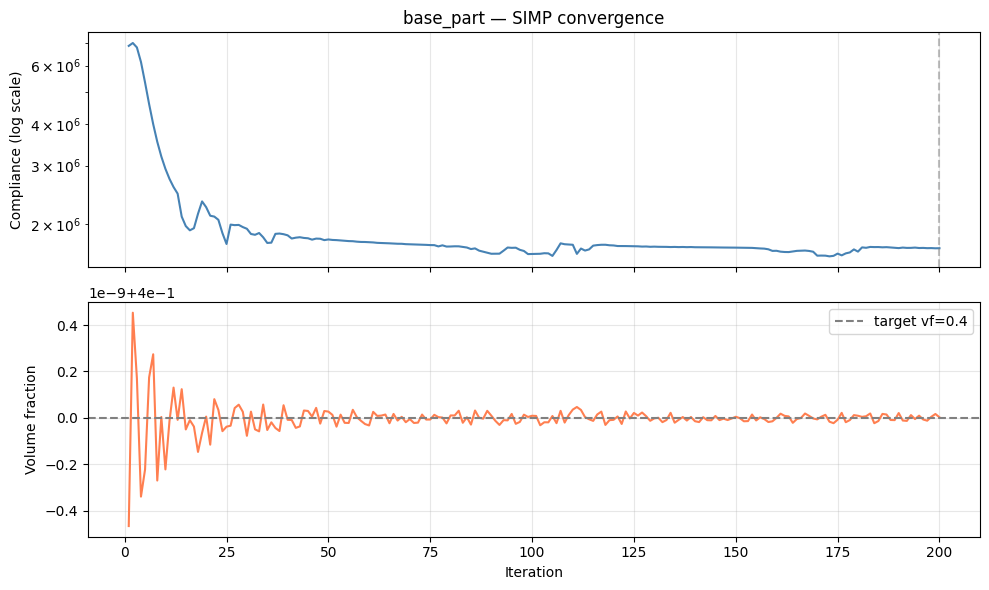

Convergence plot: outputs/reports/base_part_convergence.png


In [5]:
# Cell 4 — Plot compliance and volume fraction history
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

iters = np.arange(1, len(result.compliance_history) + 1)

ax1.semilogy(iters, result.compliance_history, color="steelblue", linewidth=1.5)
ax1.set_ylabel("Compliance (log scale)")
ax1.set_title(f"{part_name} — SIMP convergence")
ax1.axvline(result.n_iterations, color="gray", linestyle="--", alpha=0.5)
ax1.grid(True, alpha=0.3)

ax2.plot(iters, result.volume_history, color="coral", linewidth=1.5)
ax2.axhline(config.volume_fraction, color="gray", linestyle="--",
            label=f"target vf={config.volume_fraction}")
ax2.set_ylabel("Volume fraction")
ax2.set_xlabel("Iteration")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
conv_path = report_dir / f"{part_name}_convergence.png"
plt.savefig(conv_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Convergence plot: {conv_path}")

Cell 5 — Final density render

In [6]:
# Cell 5 — Render final density field with threshold isosurface
if not RENDER_PLOTS:
    print("Skipping render — set RENDER_PLOTS=True after fixing display")
    # Still compute solid fraction without rendering
    import numpy as np
    rho_final = result.density_path
    print(f"Density field written to: {rho_final}")
else:
    import pyvista as pv
    from pathlib import Path

    pv.OFF_SCREEN = True

    density_mesh = pv.read(str(result.density_path))

    pl = pv.Plotter(shape=(1, 2))

    pl.subplot(0, 0)
    pl.add_mesh(density_mesh, scalars="density", cmap="bone",
                clim=[0, 1], show_edges=False)
    pl.add_text("Full density field", font_size=10)
    pl.view_isometric()

    solid = density_mesh.threshold(0.5, scalars="density")

    pl.subplot(0, 1)
    pl.add_mesh(solid, color="lightsteelblue", show_edges=True)
    pl.add_text("Thresholded (ρ > 0.5)", font_size=10)
    pl.view_isometric()

    final_png = report_dir / f"{part_name}_density_final.png"
    pl.screenshot(str(final_png))
    pl.close()
    print(f"Final density render: {final_png}")

    solid_fraction = solid.n_cells / density_mesh.n_cells
    print(f"Solid elements (ρ>0.5): {solid.n_cells:,} / "
          f"{density_mesh.n_cells:,} ({solid_fraction*100:.1f}%)")

Skipping render — set RENDER_PLOTS=True after fixing display
Density field written to: outputs/meshes/base_part_density.xdmf


Cell 6 — Write Stage 4 handoff

In [7]:
# Cell 6 — Handoff for 05_stl_export.ipynb
import json
from pathlib import Path

handoff_out = {
    "stage":              "04_simp",
    "part_name":          part_name,
    "density_path":       str(result.density_path),
    "xdmf_path":          str(xdmf_path),
    "n_iterations":       result.n_iterations,
    "converged":          result.converged,
    "final_compliance":   result.final_compliance,
    "final_volume_frac":  result.final_volume_frac,
    "duration_s":         result.duration_s,
    "config": {
        "volume_fraction": config.volume_fraction,
        "penal":           config.penal,
        "filter_radius":   config.filter_radius,
        "convergence_tol": config.convergence_tol,
    },
    "material":           material,
    "load_hints":         load_hints,
}

handoff_path_out = Path("outputs/meshes") / f"{part_name}_stage04.json"
handoff_path_out.write_text(json.dumps(handoff_out, indent=2))
print(f"Handoff written: {handoff_path_out}")
print(json.dumps(handoff_out, indent=2))

Handoff written: outputs/meshes/base_part_stage04.json
{
  "stage": "04_simp",
  "part_name": "base_part",
  "density_path": "outputs/meshes/base_part_density.xdmf",
  "xdmf_path": "outputs/meshes/opt_domain.xdmf",
  "n_iterations": 200,
  "converged": false,
  "final_compliance": 1694431.432607823,
  "final_volume_frac": 0.400000000002725,
  "duration_s": 55.188,
  "config": {
    "volume_fraction": 0.4,
    "penal": 3.0,
    "filter_radius": 5.0,
    "convergence_tol": 0.01
  },
  "material": {
    "youngs_modulus_pa": 210000000000.0,
    "poissons_ratio": 0.3,
    "name": "steel"
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 10000.0
  }
}


How Stage 4 connects to Stage 5
Two things travel forward:
density_path — the XDMF file containing the final rho field on the DG0 mesh. Stage 5 reads this, applies a threshold (default 0.5), and runs marching cubes via scikit-image to extract the isosurface as a triangle mesh. The threshold is configurable in Stage 5 — raising it (e.g. 0.6) gives a more conservative, heavier result; lowering it (e.g. 0.4) gives a lighter but more fragile one.
xdmf_path — the original mesh. Stage 5 needs the node coordinates to map the DG0 density field onto a regular voxel grid before marching cubes can run, since marching cubes expects a structured grid rather than an unstructured tet mesh.
The most important parameter connecting Stage 4 to Stage 5 is filter_radius. If it's too small relative to target_element_size, the density field will contain checkerboard noise that marching cubes turns into physically unmakeable thin spikes and disconnected islands in the STL. If your Stage 5 STL looks spiky or has disconnected components, come back here and increase FILTER_RADIUS by 50% and re-run from Cell 3.